In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'D:\AI-Projects\Machine-Learning\Data\insurance_regression.csv')

print(df.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
df.tail()


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
print("Shape:", df.shape)

Shape: (1338, 7)


In [ ]:
print("Columns:", list(df.columns))

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [ ]:
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [ ]:
# Missing values
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
print((df.isnull().sum()/len(df)*100).round(2))

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64


In [ ]:
# Duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

Duplicate rows: 1


In [ ]:
# Data types
print(df.dtypes)  # age/children should be int, bmi/charges float, rest categorical - already correct



age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [ ]:
# Unique values of categorical columns
for c in ['sex', 'smoker', 'region']:
    print(c, ':', df[c].unique())

sex : ['female' 'male']
smoker : ['yes' 'no']
region : ['southwest' 'southeast' 'northwest' 'northeast']


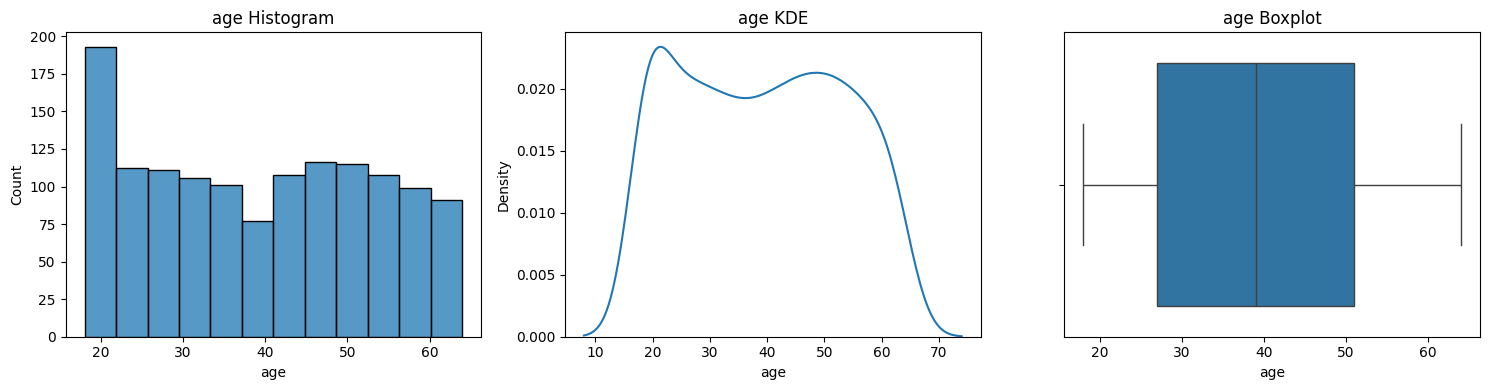

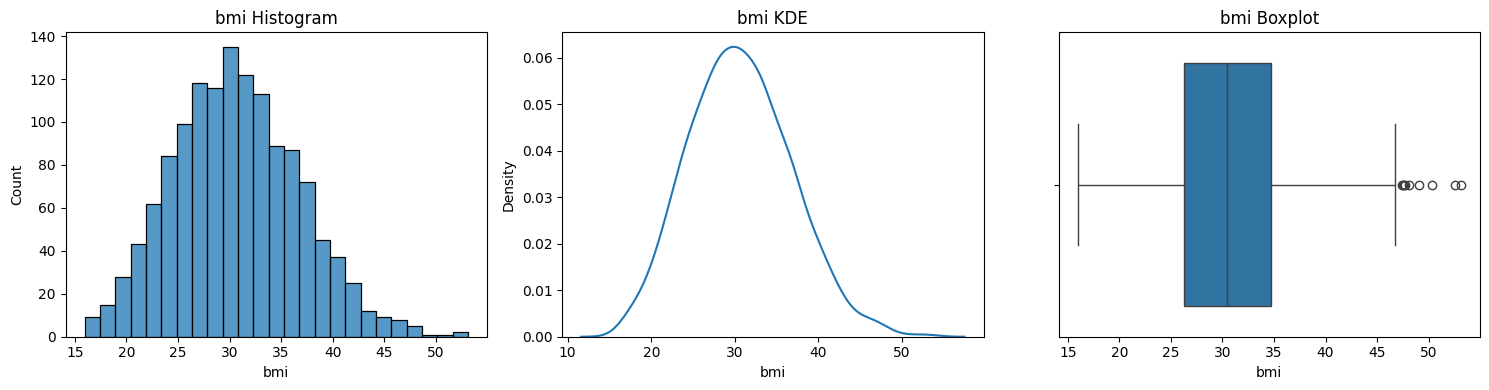

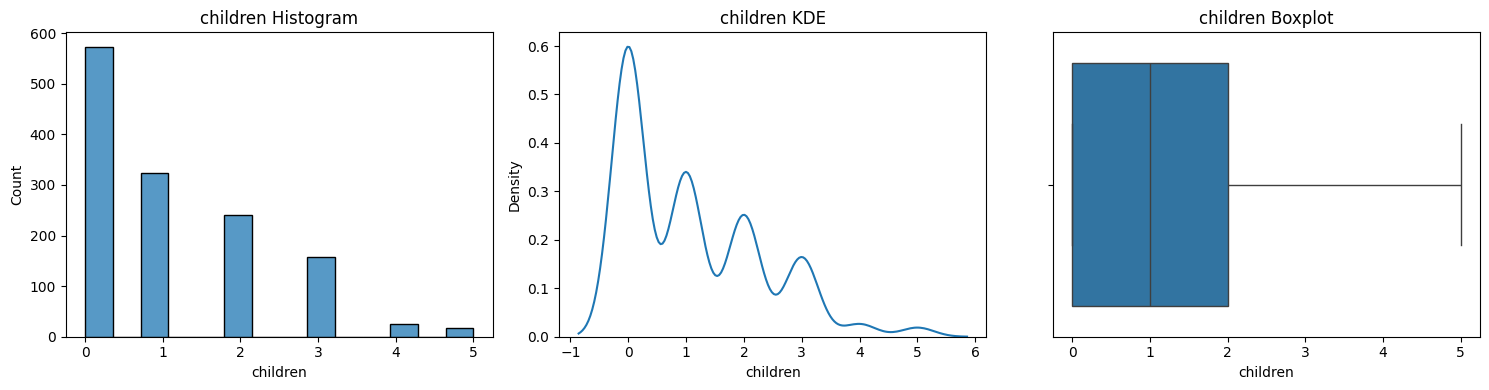

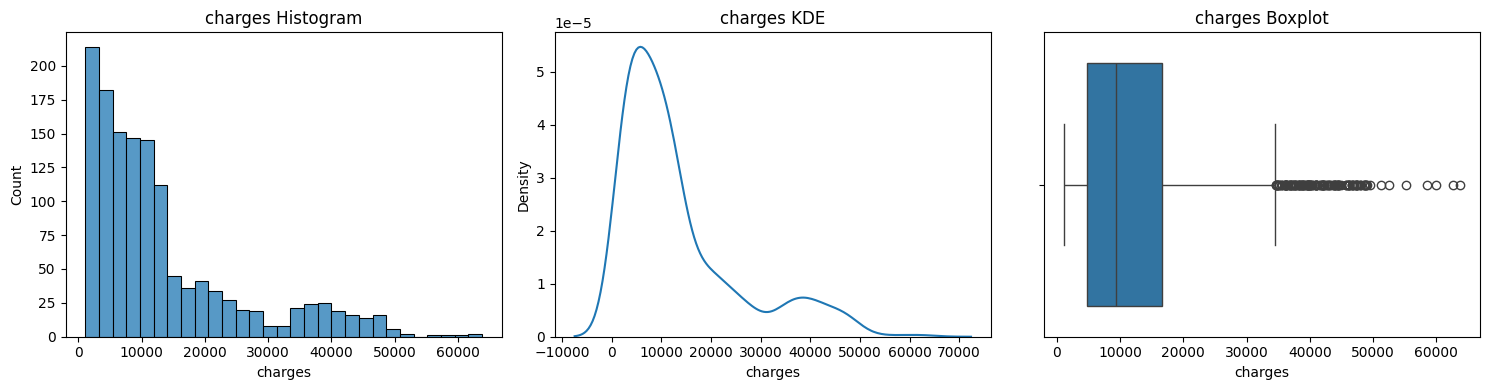

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['age', 'bmi', 'children', 'charges']
cat_cols = ['sex', 'smoker', 'region']

# --- Univariate: numerical ---
for c in num_cols:
    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    sns.histplot(df[c], kde=False, ax=axes[0]); axes[0].set_title(f'{c} Histogram')
    sns.kdeplot(df[c], ax=axes[1]); axes[1].set_title(f'{c} KDE')
    sns.boxplot(x=df[c], ax=axes[2]); axes[2].set_title(f'{c} Boxplot')
    plt.tight_layout(); plt.show()



In [ ]:
print(df[num_cols].skew())

age         0.054781
bmi         0.283914
children    0.937421
charges     1.515391
dtype: float64


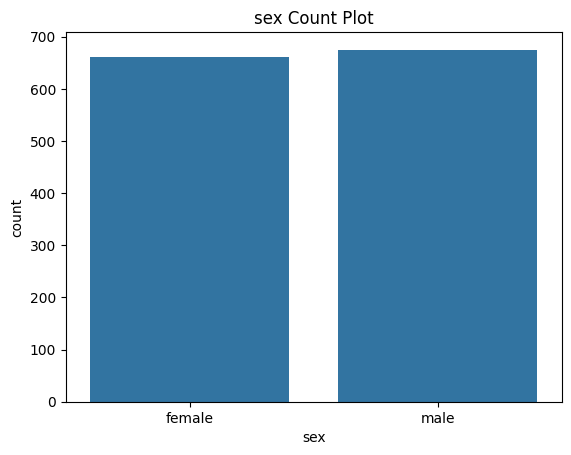

sex
male      675
female    662
Name: count, dtype: int64


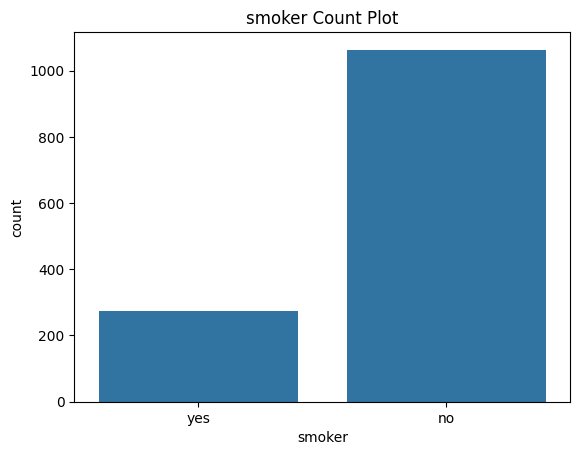

smoker
no     1063
yes     274
Name: count, dtype: int64


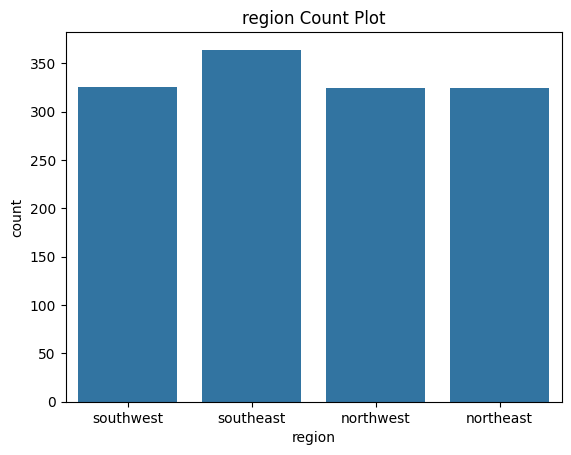

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [ ]:
# --- Univariate: categorical ---
for c in cat_cols:
    sns.countplot(x=df[c]); plt.title(f'{c} Count Plot'); plt.show()
    print(df[c].value_counts())


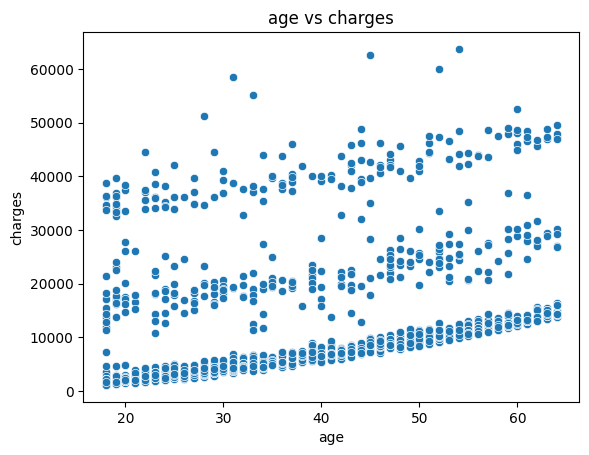

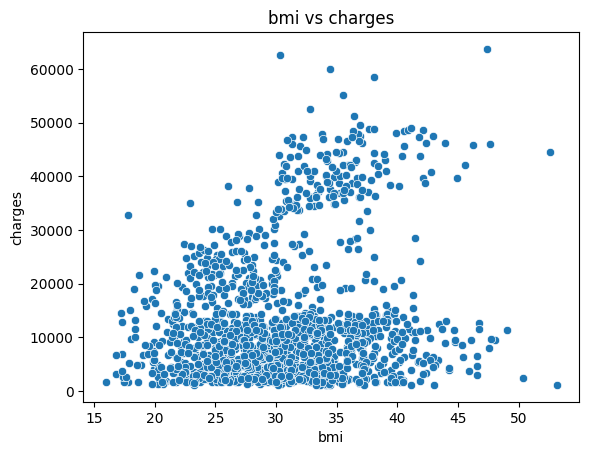

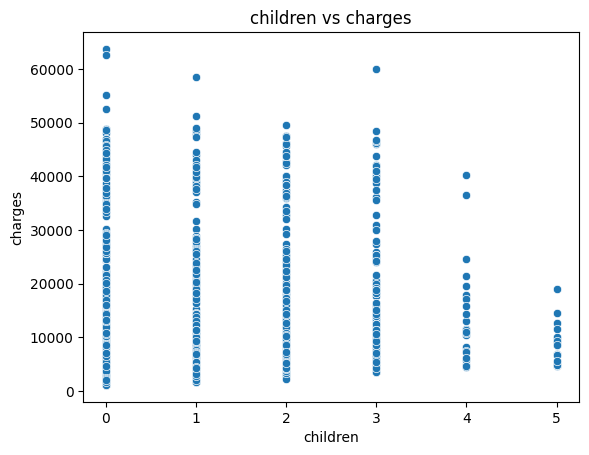

In [ ]:
# --- Bivariate ---
for c in ['age','bmi','children']:
    sns.scatterplot(x=df[c], y=df['charges']); plt.title(f'{c} vs charges'); plt.show()

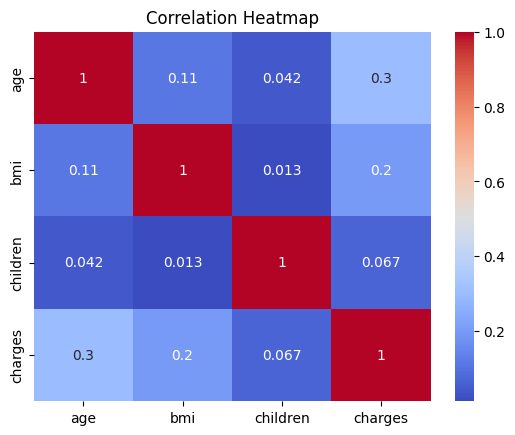

In [ ]:
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm'); plt.title('Correlation Heatmap'); plt.show()


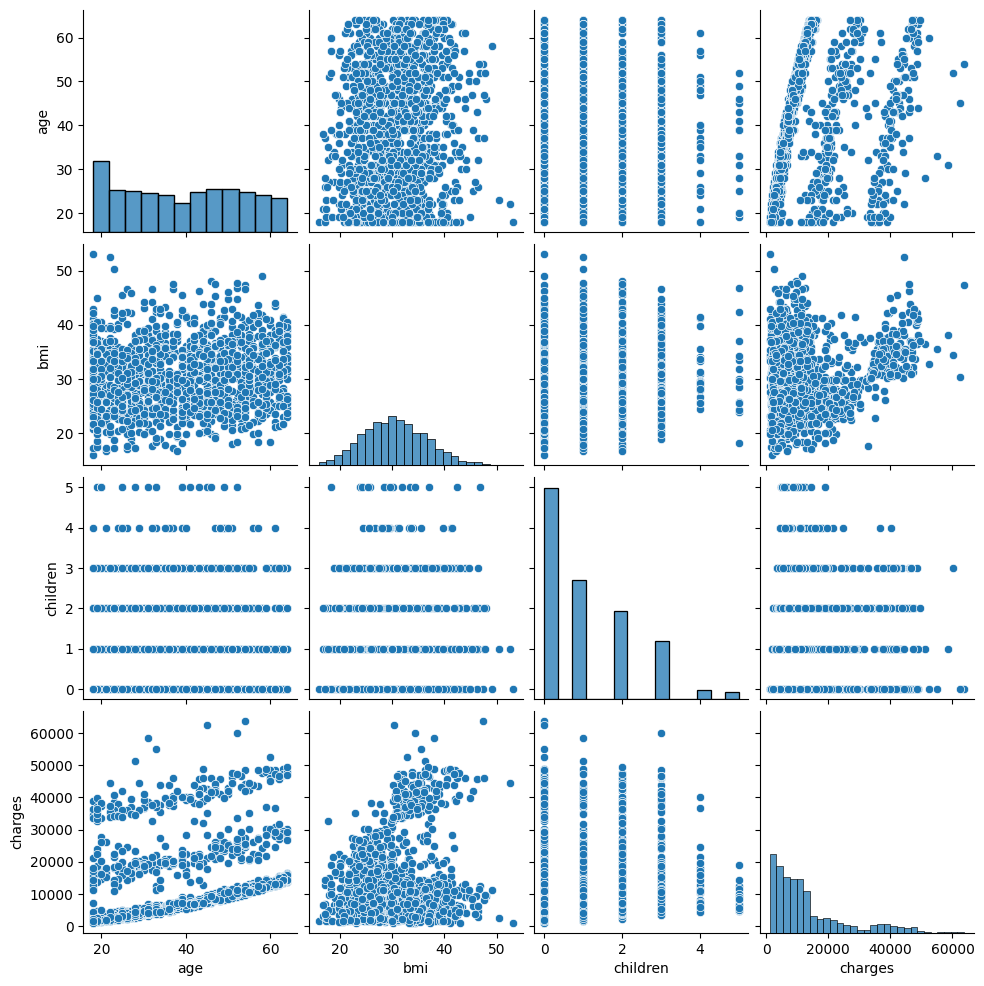

In [ ]:
sns.pairplot(df[num_cols]); plt.show()

In [ ]:
from scipy import stats

for c in num_cols:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers_iqr = df[(df[c] < low) | (df[c] > high)]

    z = np.abs(stats.zscore(df[c]))
    outliers_z = df[z > 3]

    print(f"{c}: IQR outliers={len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%), "
          f"Z-score outliers={len(outliers_z)} ({len(outliers_z)/len(df)*100:.2f}%)")

age: IQR outliers=0 (0.00%), Z-score outliers=0 (0.00%)
bmi: IQR outliers=9 (0.67%), Z-score outliers=4 (0.30%)
children: IQR outliers=0 (0.00%), Z-score outliers=18 (1.35%)
charges: IQR outliers=139 (10.40%), Z-score outliers=7 (0.52%)


In [ ]:
from scipy import stats

df_clean = df.copy()

for c in num_cols:
    Q1, Q3 = df_clean[c].quantile(0.25), df_clean[c].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    before = df_clean.shape[0]
    df_clean = df_clean[(df_clean[c] >= low) & (df_clean[c] <= high)]
    after = df_clean.shape[0]
    print(f"{c}: removed {before - after} rows (bounds: {low:.2f} to {high:.2f})")

print("\nOriginal shape:", df.shape)
print("Shape after outlier removal:", df_clean.shape)

age: removed 0 rows (bounds: -9.00 to 87.00)
bmi: removed 9 rows (bounds: 13.67 to 47.32)
children: removed 0 rows (bounds: -3.00 to 5.00)
charges: removed 138 rows (bounds: -13045.64 to 34394.27)

Original shape: (1337, 7)
Shape after outlier removal: (1190, 7)


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

# Encoding
le_sex = LabelEncoder()
df['sex_enc'] = le_sex.fit_transform(df['sex'])       # binary -> Label Encoding is fine (no ordinal issue)
le_smoker = LabelEncoder()
df['smoker_enc'] = le_smoker.fit_transform(df['smoker'])  # binary -> Label Encoding

df_enc = pd.get_dummies(df, columns=['region'], drop_first=True)  # 4 categories, no order -> One-Hot Encoding

In [ ]:
feature_cols = ['age','bmi','children','sex_enc','smoker_enc'] + \
               [c for c in df_enc.columns if c.startswith('region_')]
feature_cols

['age',
 'bmi',
 'children',
 'sex_enc',
 'smoker_enc',
 'region_northwest',
 'region_southeast',
 'region_southwest']

In [ ]:
X = df_enc[feature_cols].astype(float)
y = df_enc['charges']

In [ ]:
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)   # mean=0, std=1

scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)     # scales to [0,1]

In [ ]:
print(X.assign(charges=y).corr()['charges'].sort_values(ascending=False))

from sklearn.decomposition import PCA
pca = PCA(n_components=X_std.shape[1]).fit(X_std)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

charges             1.000000
smoker_enc          0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex_enc             0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64
Explained variance ratio: [0.19216322 0.16583517 0.13704414 0.132862   0.11938031 0.11569408
 0.09775907 0.039262  ]
Cumulative: [0.19216322 0.35799838 0.49504252 0.62790453 0.74728484 0.86297892
 0.960738   1.        ]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# fit scalers on TRAIN ONLY, then transform both, to avoid data leakage
scaler_std = StandardScaler().fit(X_train)
X_train_std = scaler_std.transform(X_train)
X_test_std  = scaler_std.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor

# 1. Linear Regression
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# 2. Polynomial Regression (degree 2 and 3)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
Xtr2, Xte2 = poly2.fit_transform(X_train), poly2.transform(X_test)
m2 = LinearRegression().fit(Xtr2, y_train)
pred_poly2 = m2.predict(Xte2)

poly3 = PolynomialFeatures(degree=3, include_bias=False)
Xtr3, Xte3 = poly3.fit_transform(X_train), poly3.transform(X_test)
m3 = LinearRegression().fit(Xtr3, y_train)
pred_poly3 = m3.predict(Xte3)

# 3. Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42, max_depth=5).fit(X_train, y_train)
pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.4f}")

evaluate('Linear Regression', y_test, pred_lr)
evaluate('Polynomial (deg=2)', y_test, pred_poly2)
evaluate('Polynomial (deg=3)', y_test, pred_poly3)
evaluate('Decision Tree', y_test, pred_dt)

Linear Regression: RMSE=5956.34  MAE=4177.05  R2=0.8069
Polynomial (deg=2): RMSE=4646.06  MAE=2867.32  R2=0.8825
Polynomial (deg=3): RMSE=4870.27  MAE=3048.86  R2=0.8709
Decision Tree: RMSE=4411.54  MAE=2656.84  R2=0.8941


In [ ]:
sample = X_test.iloc[:5]
actual = y_test.iloc[:5].values
predicted = lr.predict(sample)
for a, p in zip(actual, predicted):
    print(f"Actual={a:.2f}   Predicted={p:.2f}")

Actual=8688.86   Predicted=8143.69
Actual=5708.87   Predicted=5737.12
Actual=11436.74   Predicted=14369.31
Actual=38746.36   Predicted=31745.51
Actual=4463.21   Predicted=8962.39


In [ ]:
import pickle

# --- Save Linear Regression ---
with open('model_lr.pkl', 'wb') as f:
    pickle.dump(lr, f)

# --- Save Polynomial 2 (Must save both the transformer AND the model) ---
with open('poly2_transformer.pkl', 'wb') as f:
    pickle.dump(poly2, f)
with open('model_poly2.pkl', 'wb') as f:
    pickle.dump(m2, f)

# --- Save Polynomial 3 (Must save both the transformer AND the model) ---
with open('poly3_transformer.pkl', 'wb') as f:
    pickle.dump(poly3, f)
with open('model_poly3.pkl', 'wb') as f:
    pickle.dump(m3, f)

# --- Save Decision Tree ---
with open('model_dt.pkl', 'wb') as f:
    pickle.dump(dt, f)